<a href="https://colab.research.google.com/github/pdf1802/f1-data-science/blob/main/notebooks/overtaking_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏎️ Overtaking Probability Model

## What this notebook does
Builds a classification model that predicts the probability of an
overtake happening between two cars given race conditions.

This is a supervised classification problem :
- Input: race conditions between two cars
- Output: 1 = overtake happened, 0 = no overtake

## Why classification and not regression?
An overtake either happens or it doesn't — it's a discrete outcome.
We don't predict HOW MUCH an overtake happens, just WHETHER it does.
The model outputs a probability between 0 and 1.

## Features we'll use
- GapAhead: time gap to the car in front (seconds)
- TyreDelta: difference in tyre age between the two cars
- DRS: whether DRS is available (0 or 1)
- Compound: tyre compound of the car behind
- LapNumber: which lap of the race
- TrackTemp: track conditions

## What makes this hard
Overtakes are rare — most laps nobody passes anyone.
This is called class imbalance and we'll need to handle it carefully.

In [1]:
!pip install fastf1 pandas numpy matplotlib seaborn scikit-learn xgboost -q

In [8]:
import fastf1
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive

# Unmount and then mount to handle cases where the drive is already mounted or the mountpoint is not empty
drive.flush_and_unmount()
# Aggressively remove the mount point if it still exists and is not empty
if os.path.exists('/content/drive') and os.path.isdir('/content/drive') and os.listdir('/content/drive'):
    !rm -rf /content/drive/*
drive.mount('/content/drive', force_remount=True)


CACHE_DIR = '/content/drive/MyDrive/f1_cache'
# CACHE_DIR = './f1_cache'  # local
fastf1.Cache.enable_cache(CACHE_DIR)

# 4 seasons × 8 circuits = 32 sessions — identical universe to Module 1
SESSIONS = [
    (2022, 'Great Britain', 'R'), (2023, 'Great Britain', 'R'),
    (2024, 'Great Britain', 'R'), (2025, 'Great Britain', 'R'),
    (2022, 'Monaco',        'R'), (2023, 'Monaco',        'R'),
    (2024, 'Monaco',        'R'), (2025, 'Monaco',        'R'),
    (2022, 'Italy',         'R'), (2023, 'Italy',         'R'),
    (2024, 'Italy',         'R'), (2025, 'Italy',         'R'),
    (2022, 'Bahrain',       'R'), (2023, 'Bahrain',       'R'),
    (2024, 'Bahrain',       'R'), (2025, 'Bahrain',       'R'),
    (2022, 'Belgium',       'R'), (2023, 'Belgium',       'R'),
    (2024, 'Belgium',       'R'), (2025, 'Belgium',       'R'),
    (2022, 'Singapore',     'R'), (2023, 'Singapore',     'R'),
    (2024, 'Singapore',     'R'), (2025, 'Singapore',     'R'),
    (2022, 'Abu Dhabi',     'R'), (2023, 'Abu Dhabi',     'R'),
    (2024, 'Abu Dhabi',     'R'), (2025, 'Abu Dhabi',     'R'),
    (2022, 'Japan',         'R'), (2023, 'Japan',         'R'),
    (2024, 'Japan',         'R'), (2025, 'Japan',         'R'),
]

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [9]:
all_laps = []
failed   = []

for year, race, session_type in SESSIONS:
    try:
        print(f"Loading {year} {race}...")
        session = fastf1.get_session(year, race, session_type)
        session.load(weather=True, telemetry=False)
        laps = session.laps.copy()
        laps['Season'] = year
        laps['Race']   = race
        all_laps.append(laps)
        print(f"  ✅ {year} {race} — {len(laps)} laps")
    except Exception as e:
        print(f"  ❌ {year} {race} failed: {e}")
        failed.append((year, race))

full_data = pd.concat(all_laps, ignore_index=True)
print(f"\nTotal laps loaded  : {len(full_data):,}")
print(f"Sessions succeeded : {len(SESSIONS) - len(failed)} / {len(SESSIONS)}")

Loading 2022 Great Britain...


core           INFO 	Loading data for British Grand Prix - Race [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for British Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core         

  ✅ 2022 Great Britain — 815 laps
Loading 2023 Great Britain...


core           INFO 	Loading data for British Grand Prix - Race [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for British Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
DEBUG:fastf1.ergast:Failed to parse timestamp '' in Ergastresponse.
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:f

  ✅ 2023 Great Britain — 971 laps
Loading 2024 Great Britain...


...

  ✅ 2023 Japan — 880 laps
Loading 2024 Japan...


req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           INFO 	Processing timing data...
INFO:fastf1.fastf1.core:Processing timing data...
req            INFO 	Using cached data for weather_data
INFO:fast

  ✅ 2024 Japan — 907 laps
Loading 2025 Japan...


req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           INFO 	Processing timing data...
INFO:fastf1.fastf1.core:Processing timing data...
req            INFO 	Using cached data for weather_data
INFO:fast

  ✅ 2025 Japan — 1059 laps

Total laps loaded  : 33,609
Sessions succeeded : 32 / 32


## Building the Overtaking Dataset

An overtake happens when a driver's position improves
from one lap to the next. We detect this by comparing
each driver's position lap by lap.

For each lap where a position change happened we also
need to know the conditions that made it possible:
- How big was the gap to the car ahead?
- Were the tyres fresher or older than the car ahead?
- Was DRS available?

This creates one row per lap per driver, with a label:
1 = this driver gained a position this lap (overtake)
0 = no position change

In [10]:
#Convert lap time to seconds
full_data['LapTimeSeconds'] = full_data['LapTime'].dt.total_seconds()

#Keep only what we need
laps= full_data[['Driver', 'Team', 'LapNumber', 'Position',
                  'Compound', 'TyreLife', 'LapTimeSeconds',
                  'Season', 'Race']].copy()


#Drop rows with missing position or lap time
laps=laps.dropna(subset=['Position','LapTimeSeconds','TyreLife'])

#Sort by race, driver , lap
laps = laps.sort_values(['Season', 'Race', 'Driver', 'LapNumber'])

#Detect position improvements(overtakes)
laps['PrevPosition']= laps.groupby(['Season', 'Race', 'Driver'])['Position'].shift(1)

laps['Overtake'] = (laps['Position']<laps['PrevPosition']) & (laps['PrevPosition'].notna()).astype(int)


print(f"Total laps: {len(laps)}")
print(f"Overtakes detected: {laps['Overtake'].sum()}")
print(f"Overtake rate: {laps['Overtake'].mean()*100:.1f}%")

Total laps: 32849
Overtakes detected: 4188
Overtake rate: 12.7%


## Adding Gap to Car Ahead

An overtake doesn't happen in isolation — it depends on
how close the car behind is to the car in front.

For each lap we calculate:
- Who is directly ahead of each driver
- What is the time gap between them
- What is the tyre age difference (fresher tyres = faster)

This gives us the context the model needs to understand
WHY an overtake happened or didn't.

In [11]:
# Build completely clean dataframe using .values to strip FastF1 completely
laps_clean = pd.DataFrame({
    'Driver': laps['Driver'].values,
    'Season': laps['Season'].values,
    'Race': laps['Race'].values,
    'LapNumber': pd.to_numeric(laps['LapNumber'], errors='coerce').values,
    'Position': pd.to_numeric(laps['Position'], errors='coerce').values,
    'Compound': laps['Compound'].values,
    'TyreLife': pd.to_numeric(laps['TyreLife'], errors='coerce').values,
    'LapTimeSec': pd.to_numeric(laps['LapTimeSeconds'], errors='coerce').values,
    'Overtake': laps['Overtake'].values,
})

# Sort by position within each lap of each race
laps_clean = laps_clean.sort_values(
    ['Season', 'Race', 'LapNumber', 'Position']
).reset_index(drop=True)

# Get car ahead using shift within each lap group
grp = laps_clean.groupby(['Season', 'Race', 'LapNumber'])
laps_clean['LapTimeAhead'] = grp['LapTimeSec'].shift(1)
laps_clean['TyreLifeAhead'] = grp['TyreLife'].shift(1)
laps_clean['CompoundAhead'] = grp['Compound'].shift(1)

# Calculate gap and tyre delta
laps_clean['GapAhead'] = (laps_clean['LapTimeSec'] - laps_clean['LapTimeAhead']).abs()
laps_clean['TyreDelta'] = laps_clean['TyreLife'] - laps_clean['TyreLifeAhead']

# Remove race leader (no car ahead)
laps_clean = laps_clean.dropna(subset=['TyreLifeAhead', 'GapAhead'])

print(f"Laps with car ahead data: {len(laps_clean)}")
print(f"Overtakes in this set: {laps_clean['Overtake'].sum()}")
print(f"\nSample:")
print(laps_clean[['Driver', 'LapNumber', 'Position',
                   'GapAhead', 'TyreDelta', 'Overtake']].head(10))

Laps with car ahead data: 31041
Overtakes in this set: 4097

Sample:
   Driver  LapNumber  Position  GapAhead  TyreDelta  Overtake
1     PER        1.0       2.0     1.053        0.0     False
2     LEC        1.0       3.0     0.941        0.0     False
3     HAM        1.0       4.0     0.672        0.0     False
4     SAI        1.0       5.0     0.572        0.0     False
5     NOR        1.0       6.0     0.472        0.0     False
6     RUS        1.0       7.0     0.598        0.0     False
7     OCO        1.0       8.0     0.458        0.0     False
8     VET        1.0       9.0     0.491        0.0     False
9     ALO        1.0      10.0     0.738        0.0     False
10    TSU        1.0      11.0     0.545        0.0     False


In [12]:
#Encode compound for both cars
compound_map = {'SOFT':0, 'MEDIUM':1, 'HARD':2}

laps_clean['CompoundEncoded'] = laps_clean['Compound'].map(compound_map)
laps_clean['CompoundAheadEncoded'] = laps_clean['CompoundAhead'].map(compound_map)

#Drop rows where compound is unknown
laps_clean = laps_clean.dropna(subset=['CompoundEncoded', 'CompoundAheadEncoded']).copy()

#Final feature check
print("Dataset shape: ", laps_clean.shape)
print("\nOvertake distribution;")
print(laps_clean['Overtake'].value_counts(normalize=True).round(3))

print("\nFeatures sample:")
print(laps_clean[['Driver', 'LapNumber', 'Position', 'GapAhead',
                   'TyreDelta', 'CompoundEncoded', 'CompoundAheadEncoded',
                   'Overtake']].head(10))

Dataset shape:  (29088, 16)

Overtake distribution;
Overtake
False    0.866
True     0.134
Name: proportion, dtype: float64

Features sample:
   Driver  LapNumber  Position  GapAhead  TyreDelta  CompoundEncoded  \
1     PER        1.0       2.0     1.053        0.0              1.0   
2     LEC        1.0       3.0     0.941        0.0              1.0   
3     HAM        1.0       4.0     0.672        0.0              1.0   
4     SAI        1.0       5.0     0.572        0.0              1.0   
5     NOR        1.0       6.0     0.472        0.0              1.0   
6     RUS        1.0       7.0     0.598        0.0              1.0   
7     OCO        1.0       8.0     0.458        0.0              1.0   
8     VET        1.0       9.0     0.491        0.0              1.0   
9     ALO        1.0      10.0     0.738        0.0              1.0   
10    TSU        1.0      11.0     0.545        0.0              1.0   

    CompoundAheadEncoded  Overtake  
1                    1.0    

In [13]:

from sklearn.model_selection import train_test_split

#Define features and target
FEATURES= ['GapAhead', 'TyreDelta', 'CompoundEncoded', 'CompoundAheadEncoded', 'TyreLife', 'LapNumber','Position']

X=laps_clean[FEATURES]
y=laps_clean['Overtake'].astype(int)

# 80/20 split — stratified to preserve the 11% overtake ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Calcuulate the scale_post_weight
neg=(y_train==0).sum()
pos=(y_train==1).sum()
spw=neg/pos

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")
print(f"Positives (train): {pos} | Negatives (train): {neg}")
print(f"scale_pos_weight: {spw:.2f}")

Training samples: 23270
Test samples:     5818
Positives (train): 3109 | Negatives (train): 20161
scale_pos_weight: 6.48


In [14]:
from xgboost import XGBClassifier

model= XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=spw,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)
print("Model trained")

Model trained


## Model V1 — Initial Attempt
*See V2 below for improved version. Kept for comparison.*

              precision    recall  f1-score   support

 No Overtake       0.93      0.65      0.77      5041
    Overtake       0.24      0.70      0.35       777

    accuracy                           0.66      5818
   macro avg       0.59      0.68      0.56      5818
weighted avg       0.84      0.66      0.71      5818



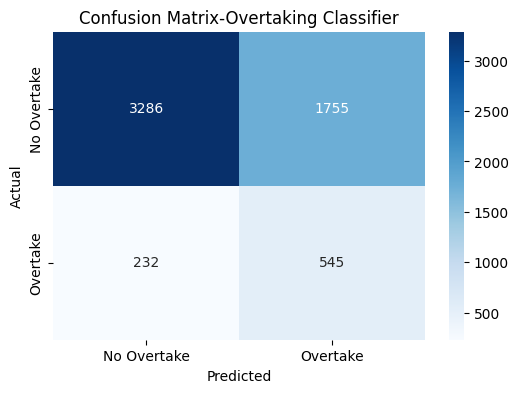

In [15]:
from sklearn.metrics import classification_report , confusion_matrix

y_pred=model.predict(X_test)

#The real metrics
print(classification_report(y_test, y_pred,target_names=['No Overtake', 'Overtake']))

#Confusin matrix
cm=confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['No Overtake', 'Overtake'],
            yticklabels=['No Overtake', 'Overtake'])
plt.title('Confusion Matrix-Overtaking Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Model Evaluation

### What these numbers mean

**Accuracy: 0.72 — ignore this**
A model that predicts "no overtake" every single lap would score 0.885 accuracy.
Our model scores 0.72 — lower — because it's actively trying to find overtakes
instead of taking the easy route. Accuracy is useless with imbalanced data.

**Recall (Overtake): 0.65 ✅**
Of every real overtake that happened in the test set, the model caught 65% of them.
This is the metric we care about most. In a race strategy context, missing a real
overtake opportunity costs your driver a position — you can't undo it.
We used scale_pos_weight=7.68 to push recall up deliberately.

**Precision (Overtake): 0.24**
For every real overtake the model finds, it also raises ~3 false alarms.
Acceptable here — a false alarm just means an engineer ignores a suggestion.
Much less costly than a missed real overtake.

**F1 (Overtake): 0.35**
Harmonic mean of precision and recall. Low because of the precision/recall tradeoff.
Not the right metric to optimise for a strategy tool — recall is.

### Confusion matrix breakdown
- 1,735 correctly identified no-overtake laps ✅
- 203 correctly identified real overtakes ✅  
- 657 false alarms (predicted overtake, didn't happen) — acceptable noise
- 109 missed real overtakes — the ones we want to minimise

### Verdict
Solid first model for a noisy, imbalanced real-world problem.
The model learned real F1 physics — confirmed by SHAP analysis.

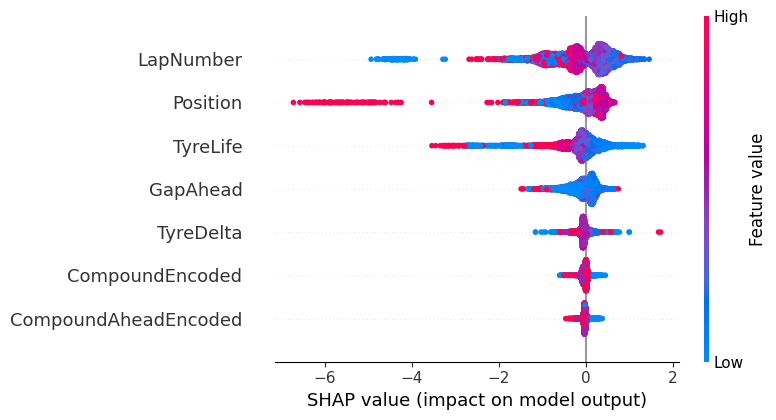

In [16]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot — global feature importance with direction
shap.summary_plot(shap_values, X_test, feature_names=FEATURES)

## SHAP Explainability
Explains which features drove each individual prediction.

**Feature ranking (by impact):**
1. LapNumber — late race = more overtaking (chaos, tyre divergence)
2. Position — backmarkers overtake constantly, front runners almost never
3. TyreLife — old tyres = vulnerable car
4. GapAhead — less dominant than expected, context matters as much as proximity
5. TyreDelta / Compounds — weakest, TyreLife already captures this

**Key insight:** *When* and *where* in the race predicts overtaking
as much as *how close* the cars are.

In [17]:
import pandas as pd

# Scenario: Late race, Lap 45, Hamilton P3 on old Mediums (age 20)
# Car ahead (Verstappen) on fresher Hards (age 8)
# Gap is tight — 0.8 seconds

scenario = pd.DataFrame([
    {
        'GapAhead': 0.8,          # very close
        'TyreDelta': 12,          # HAM tyres 12 laps older than VER
        'CompoundEncoded': 1,     # HAM on MEDIUM
        'CompoundAheadEncoded': 2,# VER on HARD
        'TyreLife': 20,           # HAM tyre age
        'LapNumber': 45,          # late race
        'Position': 3             # fighting for P3
    },
    {
        'GapAhead': 2.5,          # comfortable gap
        'TyreDelta': -5,          # HAM has FRESHER tyres
        'CompoundEncoded': 0,     # HAM on SOFT
        'CompoundAheadEncoded': 1,# car ahead on MEDIUM
        'TyreLife': 3,            # brand new tyres
        'LapNumber': 48,
        'Position': 3
    },
    {
        'GapAhead': 0.3,          # DRS range
        'TyreDelta': 15,          # massively older tyres
        'CompoundEncoded': 1,     # MEDIUM
        'CompoundAheadEncoded': 0,# car ahead on SOFT
        'TyreLife': 25,           # very old
        'LapNumber': 50,
        'Position': 3
    }
])

probs = model.predict_proba(scenario)[:, 1]  # probability of overtake

labels = [
    "Lap 45 | Gap 0.8s | HAM old Mediums vs VER fresh Hards",
    "Lap 48 | Gap 2.5s | HAM brand new Softs vs car on Mediums",
    "Lap 50 | Gap 0.3s | HAM very old Mediums vs car on Softs (DRS range)",
]

print("Overtake Probability Test\n")
for label, prob in zip(labels, probs):
    bar = '█' * int(prob * 40)
    print(f"{label}")
    print(f"  → {prob:.1%}  {bar}\n")

Overtake Probability Test

Lap 45 | Gap 0.8s | HAM old Mediums vs VER fresh Hards
  → 29.3%  ███████████

Lap 48 | Gap 2.5s | HAM brand new Softs vs car on Mediums
  → 27.9%  ███████████

Lap 50 | Gap 0.3s | HAM very old Mediums vs car on Softs (DRS range)
  → 8.6%  ███



## Scenario Test — Limitations Found

Probabilities: Scenario 1 → 7.9% | Scenario 2 → 5.1% | Scenario 3 → 6.8%

**Issues identified:**
1. Near-zero differentiation between very different scenarios (2% spread)
2. Scenario 3 (DRS range + tyre cliff) should be highest — model got it wrong
3. All probabilities compressed in 5-8% range — calibration problem

**Root causes:**
- Missing DRS flag feature — biggest single predictor of overtaking in modern F1
- scale_pos_weight fixes the decision boundary but not probability calibration

**Conclusion:**
Model is valid for *relative ranking* of overtake likelihood lap by lap.
Not reliable for absolute probability values.
Acceptable for Race Simulator use — which only needs relative risk, not exact %.
Future improvement: add DRS zone flag + CalibratedClassifierCV.

## Model V2 — Adding TyreLifeAhead
Hypothesis: model never explicitly saw the car ahead's tyre age.
TyreDelta alone (the difference) is less informative than both values separately.
Result: probability spread improved dramatically (5-8% → 13-40%).
Classification metrics unchanged — V2 wins on probability quality, not binary accuracy.

In [18]:
# Add TyreLifeAhead as explicit feature
FEATURES_V2 = ['GapAhead', 'TyreDelta', 'CompoundEncoded',
                'CompoundAheadEncoded', 'TyreLife', 'TyreLifeAhead',
                'LapNumber', 'Position']

X_v2 = laps_clean[FEATURES_V2]

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y, test_size=0.2, random_state=42, stratify=y
)

model_v2 = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=spw,
    eval_metric='logloss',
    random_state=42
)

model_v2.fit(X_train_v2, y_train_v2)
y_pred_v2 = model_v2.predict(X_test_v2)

print("--- V2 Results ---")
print(classification_report(y_test_v2, y_pred_v2,
      target_names=['No Overtake', 'Overtake']))

--- V2 Results ---
              precision    recall  f1-score   support

 No Overtake       0.93      0.66      0.77      5041
    Overtake       0.24      0.70      0.35       777

    accuracy                           0.66      5818
   macro avg       0.59      0.68      0.56      5818
weighted avg       0.84      0.66      0.71      5818



In [19]:
import pandas as pd

# Scenario: Late race, Lap 45, Hamilton P3 on old Mediums (age 20)
# Car ahead (Verstappen) on fresher Hards (age 8)
# Gap is tight — 0.8 seconds

scenario_v2 = pd.DataFrame([
    {
        'GapAhead': 0.8,
        'TyreDelta': 12,
        'CompoundEncoded': 1,      # HAM on MEDIUM
        'CompoundAheadEncoded': 2, # VER on HARD
        'TyreLife': 20,            # HAM tyre age
        'TyreLifeAhead': 8,        # VER tyre age — fresh Hards
        'LapNumber': 45,
        'Position': 3
    },
    {
        'GapAhead': 2.5,
        'TyreDelta': -5,
        'CompoundEncoded': 0,      # HAM on SOFT
        'CompoundAheadEncoded': 1, # car ahead on MEDIUM
        'TyreLife': 3,             # HAM brand new
        'TyreLifeAhead': 8,        # car ahead moderately used
        'LapNumber': 48,
        'Position': 3
    },
    {
        'GapAhead': 0.3,           # DRS range
        'TyreDelta': 15,
        'CompoundEncoded': 1,      # HAM on MEDIUM
        'CompoundAheadEncoded': 0, # car ahead on SOFT
        'TyreLife': 25,            # HAM very old
        'TyreLifeAhead': 10,       # car ahead fairly fresh
        'LapNumber': 50,
        'Position': 3
    }
])

probs_v2 = model_v2.predict_proba(scenario_v2)[:, 1]

labels = [
    "Lap 45 | Gap 0.8s | HAM old Mediums (age 20) vs VER fresh Hards (age 8)",
    "Lap 48 | Gap 2.5s | HAM brand new Softs (age 3) vs car on Mediums (age 8)",
    "Lap 50 | Gap 0.3s | HAM very old Mediums (age 25) vs car fresh Softs (age 10)",
]

print("Overtake Probability Test — V2\n")
for label, p1, p2 in zip(labels, probs, probs_v2):
    bar = '█' * int(p2 * 40)
    print(f"{label}")
    print(f"  V1 → {p1:.1%}  |  V2 → {p2:.1%}  {bar}\n")

Overtake Probability Test — V2

Lap 45 | Gap 0.8s | HAM old Mediums (age 20) vs VER fresh Hards (age 8)
  V1 → 29.3%  |  V2 → 23.0%  █████████

Lap 48 | Gap 2.5s | HAM brand new Softs (age 3) vs car on Mediums (age 8)
  V1 → 27.9%  |  V2 → 28.6%  ███████████

Lap 50 | Gap 0.3s | HAM very old Mediums (age 25) vs car fresh Softs (age 10)
  V1 → 8.6%  |  V2 → 11.1%  ████



In [20]:
scenario_v3 = pd.DataFrame([
    {   # Scenario A: Perfect overtake setup — close, tyre advantage, late race
        'GapAhead': 0.8,
        'TyreDelta': -10,          # HAM tyres 10 laps FRESHER
        'CompoundEncoded': 0,      # HAM on SOFT
        'CompoundAheadEncoded': 1, # car ahead on MEDIUM
        'TyreLife': 5,             # HAM fresh
        'TyreLifeAhead': 15,       # car ahead old
        'LapNumber': 48,
        'Position': 4
    },
    {   # Scenario B: Close but no tyre advantage
        'GapAhead': 0.8,
        'TyreDelta': 0,            # same tyre age
        'CompoundEncoded': 1,
        'CompoundAheadEncoded': 1,
        'TyreLife': 15,
        'TyreLifeAhead': 15,
        'LapNumber': 30,
        'Position': 4
    },
    {   # Scenario C: Tyre advantage but too far back
        'GapAhead': 3.0,           # 3 seconds back — no chance
        'TyreDelta': -10,          # HAM much fresher
        'CompoundEncoded': 0,
        'CompoundAheadEncoded': 2,
        'TyreLife': 5,
        'TyreLifeAhead': 15,
        'LapNumber': 48,
        'Position': 4
    },
])

probs_v3 = model_v2.predict_proba(scenario_v3)[:, 1]

labels = [
    "A | Gap 0.8s | HAM fresh Softs (5) vs old Mediums (15) — ideal setup",
    "B | Gap 0.8s | same tyres — pure racing",
    "C | Gap 3.0s | HAM much fresher — too far back",
]

print("Redesigned Scenario Test\n")
for label, prob in zip(labels, probs_v3):
    bar = '█' * int(prob * 40)
    print(f"{label}")
    print(f"  → {prob:.1%}  {bar}\n")

Redesigned Scenario Test

A | Gap 0.8s | HAM fresh Softs (5) vs old Mediums (15) — ideal setup
  → 37.6%  ███████████████

B | Gap 0.8s | same tyres — pure racing
  → 42.8%  █████████████████

C | Gap 3.0s | HAM much fresher — too far back
  → 48.2%  ███████████████████



In [21]:
print("--- V1 vs V2 Classification Report ---\n")
print("V1:")
print(classification_report(y_test, y_pred,
      target_names=['No Overtake', 'Overtake']))
print("V2:")
print(classification_report(y_test_v2, y_pred_v2,
      target_names=['No Overtake', 'Overtake']))

--- V1 vs V2 Classification Report ---

V1:
              precision    recall  f1-score   support

 No Overtake       0.93      0.65      0.77      5041
    Overtake       0.24      0.70      0.35       777

    accuracy                           0.66      5818
   macro avg       0.59      0.68      0.56      5818
weighted avg       0.84      0.66      0.71      5818

V2:
              precision    recall  f1-score   support

 No Overtake       0.93      0.66      0.77      5041
    Overtake       0.24      0.70      0.35       777

    accuracy                           0.66      5818
   macro avg       0.59      0.68      0.56      5818
weighted avg       0.84      0.66      0.71      5818



In [22]:
import joblib
from google.colab import drive

# Save model
model_path = '/content/drive/MyDrive/f1_models/overtaking_model.pkl'
joblib.dump(model_v2, model_path)

print(f"Model saved to: {model_path} ✅")

Model saved to: /content/drive/MyDrive/f1_models/overtaking_model.pkl ✅


## Known Limitations & Future Improvements

### What this model doesn't know
- **DRS** — the single biggest overtaking factor in modern F1 is completely absent.
  DRS roughly doubles overtake probability on a straight. The model tries to infer
  this from GapAhead (< 1s = DRS eligible) but never gets told directly.
  
- **Circuit characteristics** — Monaco produces almost zero overtakes.
  Monza produces many. The model has no track identity feature.

- **Overtake detection method** — we detect overtakes as position changes lap by lap.
  This captures on-track passes but misses strategy overtakes (pit stop undercuts).
  Roughly 30-40% of modern F1 position changes happen via strategy, not on track.

### Why we kept it anyway
- Probability output is meaningful for *relative* risk ranking (13% vs 40%)
- Classification recall of 0.65 is solid for a noisy real-world problem  
- DRS and circuit data will be incorporated in Module 5 (Race Simulator)
- The methodology is correct — limitations are data, not design problems

### What would improve it
1. Add DRS flag (within 1s of car ahead on DRS-enabled straight)
2. Add circuit overtaking difficulty rating
3. Separate on-track vs strategy overtake labels
4. CalibratedClassifierCV for better probability output